# BIC를 AIC로 바꿈

In [2]:
import os
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
from tqdm.auto import tqdm, trange
import joblib
import time
from sklearn.decomposition import PCA
import warnings

# 경고 메시지 무시
warnings.filterwarnings('ignore', category=UserWarning)

# ================================================================
# 1. 기본 설정 및 경로 정의
# ================================================================
print("Step 1: 기본 설정 로드")
DEVICE = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
DATA_DIR = '/home/nas/data/YMG/datas/celeba_hq_256/'

# --- 모델 경로 ---
AE_CHECKPOINT_DIR = '/home/nas/data/YMG/superdeep_ae/checkpoints/'
ENCODER_PATH = os.path.join(AE_CHECKPOINT_DIR, 'encoder_superdeep_best.pth')

# --- 결과 저장 경로 ---
OUTPUT_DIR = '/home/nas/data/YMG/superdeep_ae/hierarchical_gmm_aic_results/'
os.makedirs(OUTPUT_DIR, exist_ok=True)


# ================================================================
# 2. 필요한 클래스 및 함수 정의
# ================================================================
print("Step 2: 모델 및 유틸리티 클래스 정의")

class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(nn.Conv2d(in_channels, out_channels, 3, 1, 1), nn.BatchNorm2d(out_channels), nn.SiLU(), nn.Conv2d(out_channels, out_channels, 3, 1, 1), nn.BatchNorm2d(out_channels))
        self.shortcut = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()
        self.silu = nn.SiLU()
    def forward(self, x): return self.silu(self.block(x) + self.shortcut(x))

class EncoderSuperDeep(nn.Module):
    def __init__(self, in_channels=3, base_channels=128, latent_channels=1):
        super().__init__()
        self.encoder = nn.Sequential(nn.Conv2d(in_channels, base_channels, 3, 1, 1), ResBlock(base_channels, base_channels), nn.Conv2d(base_channels, base_channels*2, 3, 2, 1), ResBlock(base_channels*2, base_channels*2), nn.Conv2d(base_channels*2, base_channels*4, 3, 2, 1), ResBlock(base_channels*4, base_channels*4), nn.Conv2d(base_channels*4, base_channels*8, 3, 2, 1), ResBlock(base_channels*8, base_channels*8), nn.Conv2d(base_channels*8, base_channels*16, 3, 2, 1), ResBlock(base_channels*16, base_channels*16), nn.Conv2d(base_channels*16, 2 * latent_channels, 3, 1, 1))
    def forward(self, x):
        x = self.encoder(x)
        mu, log_var = torch.chunk(x, 2, dim=1)
        return mu, log_var

class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.paths = sorted([os.path.join(root_dir, f) for f in os.listdir(root_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))])
        self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, idx

class PyTorchGMM:
    def __init__(self, n_components, max_iter=200, tol=1e-8, reg_covar=1e-6, random_state=42):
        self.n_components, self.max_iter, self.tol = n_components, max_iter, tol
        self.reg_covar, self.random_state = reg_covar, random_state
        self.device = DEVICE
        self.weights_, self.means_, self.covariances_ = None, None, None
        self.converged_ = False
        self.log_likelihood_ = -torch.inf

    def fit(self, X, initial_means=None):
        if self.random_state: torch.manual_seed(self.random_state)
        X = X.to(self.device)
        n_samples, n_features = X.shape
        self._initialize_parameters(X, initial_means)
        log_likelihood = -torch.inf
        for i in range(self.max_iter):
            prev_log_likelihood = log_likelihood
            log_prob_norm, log_responsibilities = self._e_step(X)
            self._m_step(X, log_responsibilities)
            log_likelihood = torch.mean(log_prob_norm)
            if i > 0 and torch.abs(log_likelihood - prev_log_likelihood) < self.tol:
                self.converged_ = True
                break
        if not self.converged_: print(f"Warning: GMM with {self.n_components} components did not converge.")
        self.log_likelihood_ = torch.sum(log_prob_norm).item()

    def _initialize_parameters(self, X, initial_means):
        n_samples, n_features = X.shape
        if initial_means is not None and initial_means.shape == (self.n_components, n_features):
            self.means_ = initial_means.to(self.device)
        else:
            indices = torch.randperm(n_samples, device=self.device)[:self.n_components]
            self.means_ = X[indices]
        self.weights_ = torch.full((self.n_components,), 1/self.n_components, device=self.device)
        self.covariances_ = torch.eye(n_features, device=self.device).unsqueeze(0).repeat(self.n_components, 1, 1)

    def _e_step(self, X):
        weighted_log_prob = self._estimate_weighted_log_prob(X)
        log_prob_norm = torch.logsumexp(weighted_log_prob, dim=1)
        log_responsibilities = weighted_log_prob - log_prob_norm.unsqueeze(1)
        return log_prob_norm, log_responsibilities

    def _m_step(self, X, log_responsibilities):
        responsibilities = torch.exp(log_responsibilities)
        nk = torch.sum(responsibilities, dim=0) + 1e-10
        self.weights_ = nk / X.shape[0]
        self.means_ = torch.matmul(responsibilities.T, X) / nk.unsqueeze(1)
        for k in range(self.n_components):
            diff = X - self.means_[k]
            cov_k = torch.matmul((responsibilities[:, k].unsqueeze(1) * diff).T, diff) / nk[k]
            cov_k.add_(torch.eye(X.shape[1], device=self.device) * self.reg_covar)
            self.covariances_[k] = cov_k

    def _estimate_weighted_log_prob(self, X):
        log_probs = []
        for k in range(self.n_components):
            try:
                dist = torch.distributions.MultivariateNormal(self.means_[k], self.covariances_[k])
                log_probs.append(dist.log_prob(X))
            except ValueError:
                return torch.full((X.shape[0], self.n_components), -torch.inf, device=self.device, dtype=X.dtype)
        log_probs = torch.stack(log_probs, dim=1)
        return log_probs + torch.log(self.weights_)

class HierarchicalGMM:
    def __init__(self, max_components=30, min_points_per_component=20, random_state=42):
        self.max_components = max_components
        self.min_points = min_points_per_component
        self.random_state = random_state
        self.n_components, self.weights_, self.means_, self.covariances_ = 0, None, None, None
    
    def _calculate_aic(self, gmm):
        n_features = gmm.means_.shape[1]
        k = gmm.n_components
        n_params = (k - 1) + (k * n_features) + (k * n_features * (n_features + 1) / 2)
        return 2 * n_params - 2 * gmm.log_likelihood_

    def _split_component_and_fit(self, X, assignments, component_to_split, old_model):
        data_subset_indices = torch.where(assignments == component_to_split)[0]
        if len(data_subset_indices) < self.min_points * 2: return None
        data_subset = X[data_subset_indices]
        pca = PCA(n_components=1, random_state=self.random_state)
        pca.fit(data_subset.cpu().numpy())
        pc_vector = torch.from_numpy(pca.components_[0]).to(X.device).float()
        old_mean = old_model.means_[component_to_split]
        old_cov = old_model.covariances_[component_to_split]
        shift_magnitude = torch.sqrt(torch.max(torch.diag(old_cov)))
        initial_means = torch.stack([old_mean + pc_vector * shift_magnitude * 0.2, old_mean - pc_vector * shift_magnitude * 0.2], dim=0)
        split_gmm = PyTorchGMM(n_components=2, random_state=self.random_state)
        split_gmm.fit(data_subset, initial_means=initial_means)
        if not split_gmm.converged_: return None
        return split_gmm

    def fit(self, X):
        print("계층적 GMM 학습을 시작합니다 (기준: AIC).")
        n_samples, _ = X.shape
        best_model = PyTorchGMM(n_components=1, random_state=self.random_state)
        best_model.fit(X)
        best_aic = self._calculate_aic(best_model)
        print(f"시작 (K=1): AIC = {best_aic:.2f}")

        while best_model.n_components < self.max_components:
            current_k = best_model.n_components
            log_prob_norm, log_resp = best_model._e_step(X)
            assignments = torch.argmax(log_resp, dim=1)
            candidate_models = []

            for i in trange(current_k, desc=f"Splitting K={current_k}"):
                split_gmm = self._split_component_and_fit(X, assignments, i, best_model)
                if split_gmm is None: continue
                candidate_gmm = PyTorchGMM(n_components=current_k + 1, random_state=self.random_state)
                new_weights = list(best_model.weights_.cpu().numpy()); split_weight = new_weights.pop(i); new_weights.extend(split_gmm.weights_.cpu().numpy() * split_weight); candidate_gmm.weights_ = torch.tensor(new_weights, device=DEVICE)
                new_means = list(torch.unbind(best_model.means_, dim=0)); new_means.pop(i); new_means.extend(list(torch.unbind(split_gmm.means_, dim=0))); candidate_gmm.means_ = torch.stack(new_means, dim=0)
                new_covs = list(torch.unbind(best_model.covariances_, dim=0)); new_covs.pop(i); new_covs.extend(list(torch.unbind(split_gmm.covariances_, dim=0))); candidate_gmm.covariances_ = torch.stack(new_covs, dim=0)
                candidate_gmm.fit(X, initial_means=candidate_gmm.means_)
                aic = self._calculate_aic(candidate_gmm)
                candidate_models.append({'model': candidate_gmm, 'aic': aic})

            if not candidate_models:
                print("더 이상 분할할 수 있는 유효한 후보가 없습니다.")
                break
            
            best_candidate = min(candidate_models, key=lambda x: x['aic'])
            
            if best_candidate['aic'] < best_aic:
                best_model = best_candidate['model']
                best_aic = best_candidate['aic']
                print(f"분할 성공 (K={best_model.n_components}): Best AIC = {best_aic:.2f}")
            else:
                print("AIC가 더 이상 개선되지 않아 학습을 종료합니다.")
                break
        
        print(f"\n학습 종료. 최종 최적 컴포넌트 수: {best_model.n_components}")
        self.n_components = best_model.n_components
        self.weights_ = best_model.weights_.cpu().numpy()
        self.means_ = best_model.means_.cpu()
        self.covariances_ = best_model.covariances_.cpu()
        return self

# ================================================================
# 3. 메인 실행 파이프라인
# ================================================================
def main():
    print("\nStep 3.1: 모델 및 데이터 로드")
    encoder = EncoderSuperDeep().to(DEVICE)
    encoder.load_state_dict(torch.load(ENCODER_PATH, map_location=DEVICE))
    encoder.eval()
    print("Encoder 모델 로드 완료.")

    transform = transforms.Compose([transforms.Resize((256, 256)), transforms.ToTensor(), transforms.Normalize(mean=[0.5], std=[0.5])])
    train_dataset_full = CustomImageDataset(DATA_DIR, transform)
    train_dataset = Subset(train_dataset_full, list(range(10000)))
    loader = DataLoader(train_dataset, batch_size=64, shuffle=False, num_workers=4)

    print("\nStep 3.2: 잠재 벡터(mu) 추출")
    all_mu_vectors_flat = []
    with torch.no_grad():
        for imgs, _ in tqdm(loader, desc="잠재 벡터 추출 중"):
            imgs = imgs.to(DEVICE)
            mu, _ = encoder(imgs)
            all_mu_vectors_flat.append(mu.view(mu.size(0), -1))
    latent_vectors_tensor = torch.cat(all_mu_vectors_flat, dim=0)
    print(f"총 {latent_vectors_tensor.shape[0]}개의 잠재 벡터 추출 완료 (차원: {latent_vectors_tensor.shape[1]}).")

    print("\nStep 3.3: 계층적 GMM 학습 시작")
    hgmm = HierarchicalGMM(max_components=30)
    start_time = time.time()
    hgmm.fit(latent_vectors_tensor)
    elapsed_time = time.time() - start_time
    print(f"GMM fitting 완료. 소요 시간: {elapsed_time:.2f}초")

    print("\nStep 3.4: 최적 GMM 파라미터 저장")
    gmm_state_dict = {
        'weights': hgmm.weights_,
        'means': hgmm.means_.numpy(),
        'covariances': hgmm.covariances_.numpy(),
        'n_components': hgmm.n_components
    }
    save_path = os.path.join(OUTPUT_DIR, f'hgmm_aic_best_{hgmm.n_components}_components.pkl')
    joblib.dump(gmm_state_dict, save_path)
    print(f"최적 GMM 파라미터 저장 완료: {save_path}")

if __name__ == '__main__':
    main()

Step 1: 기본 설정 로드
Step 2: 모델 및 유틸리티 클래스 정의

Step 3.1: 모델 및 데이터 로드


/tmp/ipykernel_2447027/1448436679.py:210: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  encoder.load_state_dict(torch.load(ENCODER_PATH, map_location=DEVICE))


Encoder 모델 로드 완료.

Step 3.2: 잠재 벡터(mu) 추출


잠재 벡터 추출 중:   0%|          | 0/157 [00:00<?, ?it/s]

총 10000개의 잠재 벡터 추출 완료 (차원: 256).

Step 3.3: 계층적 GMM 학습 시작
계층적 GMM 학습을 시작합니다 (기준: AIC).
시작 (K=1): AIC = 6001052.50


...

분할 성공 (K=3): Best AIC = 5922822.00


Splitting K=3:   0%|          | 0/3 [00:00<?, ?it/s]

분할 성공 (K=4): Best AIC = 5897694.50


Splitting K=4:   0%|          | 0/4 [00:00<?, ?it/s]

AIC가 더 이상 개선되지 않아 학습을 종료합니다.

학습 종료. 최종 최적 컴포넌트 수: 4
GMM fitting 완료. 소요 시간: 8.98초

Step 3.4: 최적 GMM 파라미터 저장
최적 GMM 파라미터 저장 완료: /home/nas/data/YMG/superdeep_ae/hierarchical_gmm_aic_results/hgmm_aic_best_4_components.pkl


이래도 컴포넌트 4개밖에 안되네..

Step 1: 기본 설정 로드
Step 2: 모델 클래스 및 함수 정의

Step 3.1: 모델 및 데이터 로드


/tmp/ipykernel_2621594/3188201623.py:81: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  encoder.load_state_dict(torch.load(ENCODER_PATH, map_location=DEVICE))
/tmp/ipykernel_

Autoencoder 모델 로드 완료.
H-GMM(AIC) 모델 로드 완료: /home/nas/data/YMG/superdeep_ae/hierarchical_gmm_aic_results/hgmm_aic_best_4_components.pkl
최적 클러스터 수: 4

Step 3.2: 잠재 벡터 추출 및 클러스터 할당


평균 벡터(mu) 추출 중:   0%|          | 0/157 [00:00<?, ?it/s]

클러스터 할당 중:   0%|          | 0/4 [00:00<?, ?it/s]

클러스터 할당 완료.

--- 분석 1: 클러스터 분석 결과 ---
총 4개의 클러스터 중, 2개 이상의 데이터가 할당된 활성 클러스터 수: 4개

--- 분석 2: 클러스터별 샘플링 및 시각화 ---


클러스터별 비교 이미지 생성 중:   0%|          | 0/4 [00:00<?, ?it/s]

클러스터별 비교 이미지 저장 완료.

--- 분석 3: 그리드 샘플링 및 시각화 ---

--- 64개(8x8) 이미지 그리드 생성 ---
경고: 활성 클러스터 수(4개)가 샘플링할 개수(64개)보다 적어, 중복 샘플링합니다.
그리드 이미지 저장 완료: /home/nas/data/YMG/superdeep_ae/hierarchical_gmm_aic_results/grid_samples/grid_64_samples.png


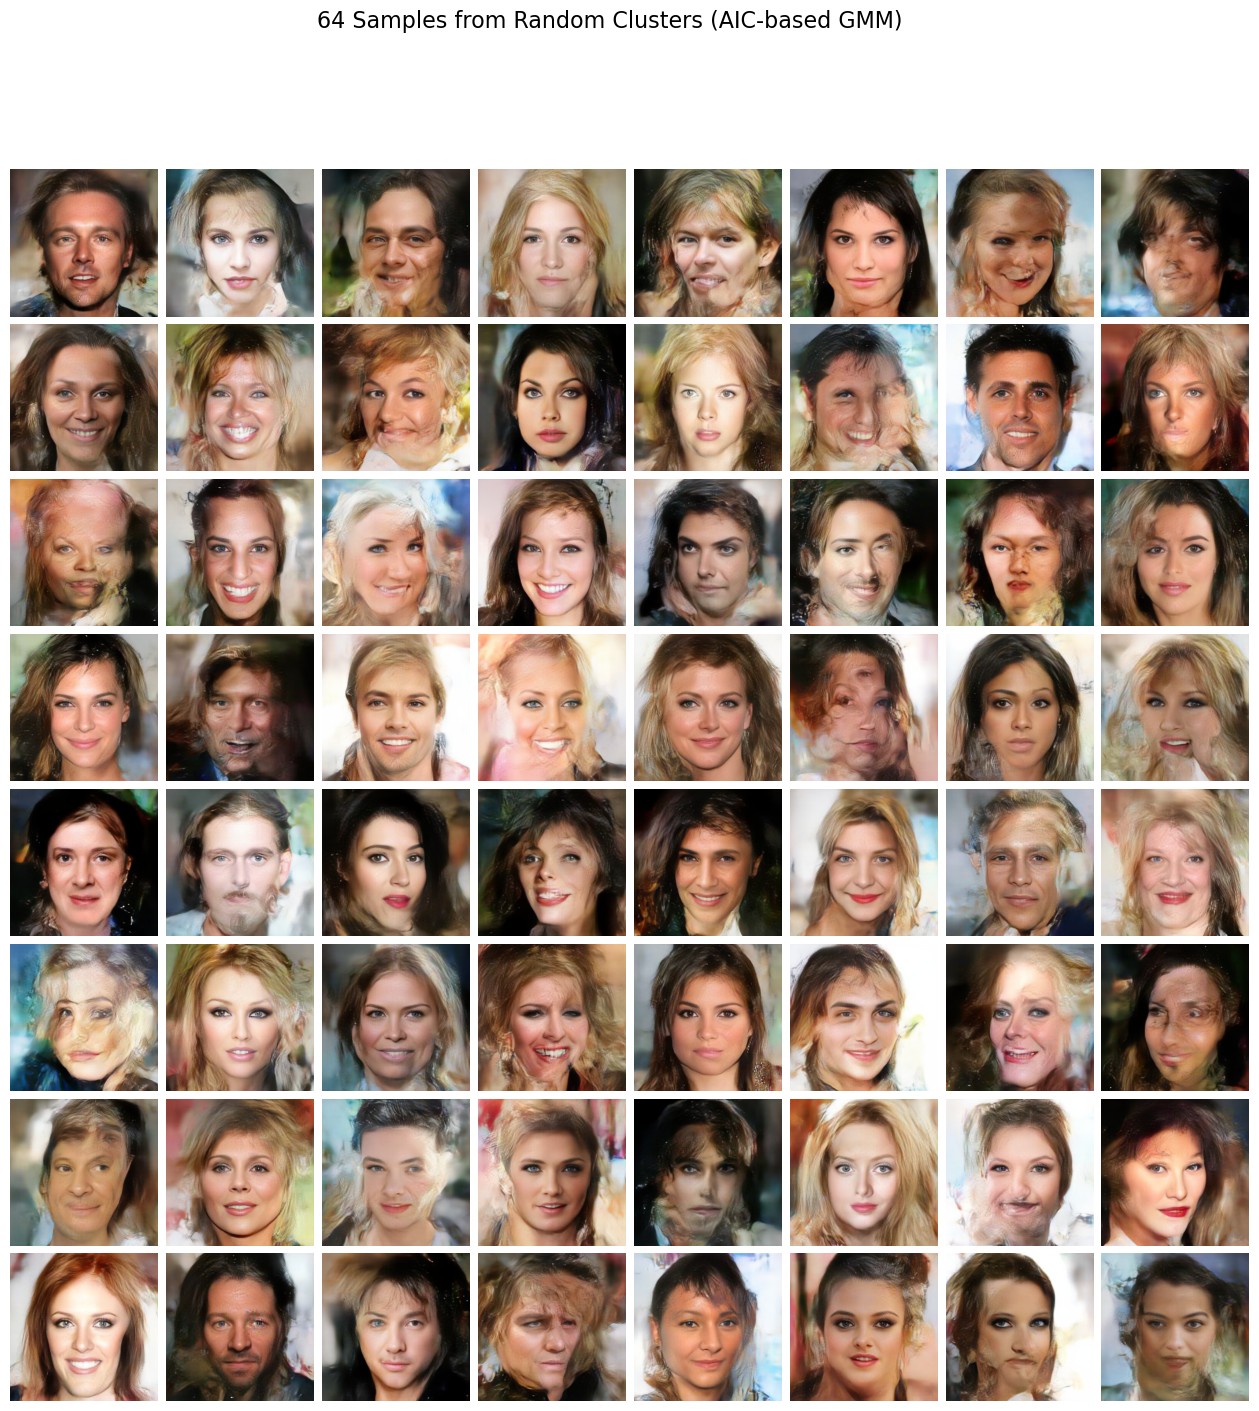

In [1]:
import os
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
from tqdm.auto import tqdm
import joblib
import matplotlib.pyplot as plt
import random

# ================================================================
# 1. 기본 설정 및 경로 정의
# ================================================================
print("Step 1: 기본 설정 로드")
DEVICE = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
DATA_DIR = '/home/nas/data/YMG/datas/celeba_hq_256/'

# --- 모델 경로 ---
AE_CHECKPOINT_DIR = '/home/nas/data/YMG/superdeep_ae/checkpoints/'
ENCODER_PATH = os.path.join(AE_CHECKPOINT_DIR, 'encoder_superdeep_best.pth')
DECODER_PATH = os.path.join(AE_CHECKPOINT_DIR, 'decoder_superdeep_best.pth')

# --- H-GMM(AIC) 모델 경로 ---
GMM_DIR = '/home/nas/data/YMG/superdeep_ae/hierarchical_gmm_aic_results/'

# --- 결과 저장 경로 ---
OUTPUT_DIR = GMM_DIR
os.makedirs(os.path.join(OUTPUT_DIR, 'cluster_comparisons'), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, 'grid_samples'), exist_ok=True)


# ================================================================
# 2. 필요한 클래스 및 함수 정의
# ================================================================
print("Step 2: 모델 클래스 및 함수 정의")
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(nn.Conv2d(in_channels, out_channels, 3, 1, 1), nn.BatchNorm2d(out_channels), nn.SiLU(), nn.Conv2d(out_channels, out_channels, 3, 1, 1), nn.BatchNorm2d(out_channels))
        self.shortcut = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()
        self.silu = nn.SiLU()
    def forward(self, x): return self.silu(self.block(x) + self.shortcut(x))

class EncoderSuperDeep(nn.Module):
    def __init__(self, in_channels=3, base_channels=128, latent_channels=1):
        super().__init__()
        self.encoder = nn.Sequential(nn.Conv2d(in_channels, base_channels, 3, 1, 1), ResBlock(base_channels, base_channels), nn.Conv2d(base_channels, base_channels*2, 3, 2, 1), ResBlock(base_channels*2, base_channels*2), nn.Conv2d(base_channels*2, base_channels*4, 3, 2, 1), ResBlock(base_channels*4, base_channels*4), nn.Conv2d(base_channels*4, base_channels*8, 3, 2, 1), ResBlock(base_channels*8, base_channels*8), nn.Conv2d(base_channels*8, base_channels*16, 3, 2, 1), ResBlock(base_channels*16, base_channels*16), nn.Conv2d(base_channels*16, 2 * latent_channels, 3, 1, 1))
    def forward(self, x):
        x = self.encoder(x)
        mu, log_var = torch.chunk(x, 2, dim=1)
        return mu, log_var

class DecoderSuperDeep(nn.Module):
    def __init__(self, out_channels=3, base_channels=128, latent_channels=1):
        super().__init__()
        self.decoder = nn.Sequential(nn.Conv2d(latent_channels, base_channels*16, 3, 1, 1), ResBlock(base_channels*16, base_channels*16), nn.Upsample(scale_factor=2, mode='nearest'), nn.Conv2d(base_channels*16, base_channels*8, 3, 1, 1), ResBlock(base_channels*8, base_channels*8), nn.Upsample(scale_factor=2, mode='nearest'), nn.Conv2d(base_channels*8, base_channels*4, 3, 1, 1), ResBlock(base_channels*4, base_channels*4), nn.Upsample(scale_factor=2, mode='nearest'), nn.Conv2d(base_channels*4, base_channels*2, 3, 1, 1), ResBlock(base_channels*2, base_channels*2), nn.Upsample(scale_factor=2, mode='nearest'), nn.Conv2d(base_channels*2, base_channels, 3, 1, 1), ResBlock(base_channels, base_channels), nn.Conv2d(base_channels, out_channels, 3, 1, 1), nn.Tanh())
    def forward(self, z): return self.decoder(z)

class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.paths = sorted([os.path.join(root_dir, f) for f in os.listdir(root_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))])
        self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, idx

def denormalize(tensor):
    return (tensor.clamp(-1, 1) * 0.5) + 0.5

# ================================================================
# 3. 메인 실행 파이프라인
# ================================================================
def main():
    print("\nStep 3.1: 모델 및 데이터 로드")
    encoder = EncoderSuperDeep().to(DEVICE)
    decoder = DecoderSuperDeep().to(DEVICE)
    encoder.load_state_dict(torch.load(ENCODER_PATH, map_location=DEVICE))
    decoder.load_state_dict(torch.load(DECODER_PATH, map_location=DEVICE))
    encoder.eval(); decoder.eval()
    print("Autoencoder 모델 로드 완료.")

    # 학습된 GMM 모델 파일을 동적으로 찾기
    gmm_files = [f for f in os.listdir(GMM_DIR) if f.startswith('hgmm_aic_best_') and f.endswith('.pkl')]
    if not gmm_files:
        print(f"오류: {GMM_DIR}에서 학습된 H-GMM(AIC) 모델 파일을 찾을 수 없습니다.")
        return
    GMM_PATH = os.path.join(GMM_DIR, gmm_files[0]) # 가장 최근 파일 하나를 사용

    gmm_params = joblib.load(GMM_PATH)
    N_CLUSTERS = gmm_params['n_components']
    gmm_means = torch.from_numpy(gmm_params['means']).float().to(DEVICE)
    gmm_covs = torch.from_numpy(gmm_params['covariances']).float().to(DEVICE)
    print(f"H-GMM(AIC) 모델 로드 완료: {GMM_PATH}")
    print(f"최적 클러스터 수: {N_CLUSTERS}")

    transform = transforms.Compose([transforms.Resize((256, 256)), transforms.ToTensor(), transforms.Normalize(mean=[0.5], std=[0.5])])
    train_dataset_full = CustomImageDataset(DATA_DIR, transform)
    train_dataset = Subset(train_dataset_full, list(range(10000)))
    loader = DataLoader(train_dataset, batch_size=64, shuffle=False, num_workers=4)

    print("\nStep 3.2: 잠재 벡터 추출 및 클러스터 할당")
    all_mu_vectors_flat = []
    with torch.no_grad():
        for imgs, _ in tqdm(loader, desc="평균 벡터(mu) 추출 중"):
            imgs = imgs.to(DEVICE)
            mu, _ = encoder(imgs)
            all_mu_vectors_flat.append(mu.view(mu.size(0), -1))
    all_mu_vectors_flat = torch.cat(all_mu_vectors_flat, dim=0)
    
    log_probs = []
    for k in tqdm(range(N_CLUSTERS), desc="클러스터 할당 중"):
        dist = torch.distributions.MultivariateNormal(gmm_means[k], gmm_covs[k])
        log_probs.append(dist.log_prob(all_mu_vectors_flat))
    assignments = torch.argmax(torch.stack(log_probs, dim=1), dim=1)
    print("클러스터 할당 완료.")

    print("\n--- 분석 1: 클러스터 분석 결과 ---")
    cluster_counts = torch.bincount(assignments, minlength=N_CLUSTERS)
    active_clusters_indices = torch.where(cluster_counts > 1)[0] # 2개 이상 데이터가 있는 클러스터
    print(f"총 {N_CLUSTERS}개의 클러스터 중, 2개 이상의 데이터가 할당된 활성 클러스터 수: {len(active_clusters_indices)}개")

    print("\n--- 분석 2: 클러스터별 샘플링 및 시각화 ---")
    selected_clusters = random.sample(active_clusters_indices.tolist(), min(20, len(active_clusters_indices)))

    for cluster_idx in tqdm(selected_clusters, desc="클러스터별 비교 이미지 생성 중"):
        original_img_indices = torch.where(assignments == cluster_idx)[0]
        num_assigned = len(original_img_indices)
        mean, cov = gmm_means[cluster_idx], gmm_covs[cluster_idx]
        dist = torch.distributions.MultivariateNormal(mean, cov)
        sampled_latents = dist.sample((10,)).view(10, 1, 16, 16)

        with torch.no_grad():
            generated_imgs = decoder(sampled_latents.to(DEVICE)).cpu()

        fig, axes = plt.subplots(2, 10, figsize=(20, 4.5)); fig.suptitle(f'Cluster #{cluster_idx} (Assigned: {num_assigned})', fontsize=16)
        axes[0, 0].set_title('Original Images', loc='left'); axes[1, 0].set_title('Generated Images', loc='left')
        
        for i in range(10):
            if i < num_assigned:
                original_img, _ = train_dataset[original_img_indices[torch.randperm(num_assigned)[i]].item()]
                axes[0, i].imshow(denormalize(original_img).permute(1, 2, 0)); axes[0, i].axis('off')
            axes[1, i].imshow(denormalize(generated_imgs[i]).permute(1, 2, 0)); axes[1, i].axis('off')
        
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        save_path = os.path.join(OUTPUT_DIR, f'cluster_comparisons/cluster_{cluster_idx}_comparison.png')
        plt.savefig(save_path); plt.close(fig)
    print("클러스터별 비교 이미지 저장 완료.")

    print("\n--- 분석 3: 그리드 샘플링 및 시각화 ---")
    sample_counts = [64]
    for count in sample_counts:
        grid_size = int(np.sqrt(count))
        print(f"\n--- {count}개({grid_size}x{grid_size}) 이미지 그리드 생성 ---")
        
        if len(active_clusters_indices) < count:
            print(f"경고: 활성 클러스터 수({len(active_clusters_indices)}개)가 샘플링할 개수({count}개)보다 적어, 중복 샘플링합니다.")
            clusters_to_sample_from = random.choices(active_clusters_indices.tolist(), k=count)
        else:
            clusters_to_sample_from = random.sample(active_clusters_indices.tolist(), count)
        
        latents_list = [torch.distributions.MultivariateNormal(gmm_means[ci], gmm_covs[ci]).sample((1,)) for ci in clusters_to_sample_from]
        latents = torch.cat(latents_list, dim=0).view(count, 1, 16, 16)
        
        with torch.no_grad(): images = decoder(latents.to(DEVICE)).cpu()
        images = denormalize(images)
        
        fig, axes = plt.subplots(grid_size, grid_size, figsize=(grid_size * 2, grid_size * 2))
        fig.suptitle(f"{count} Samples from Random Clusters (AIC-based GMM)", fontsize=16)
        img_iter = iter(images)
        for ax in axes.flat: ax.imshow(next(img_iter).permute(1, 2, 0)); ax.axis('off')
        plt.subplots_adjust(wspace=0.05, hspace=0.05)
        
        save_path = os.path.join(OUTPUT_DIR, f'grid_samples/grid_{count}_samples.png')
        plt.savefig(save_path, bbox_inches='tight', pad_inches=0.1)
        print(f"그리드 이미지 저장 완료: {save_path}")
        plt.show()

if __name__ == '__main__':
    main()

In [2]:
import os
import joblib
import numpy as np

# ================================================================
# 1. 경로 설정 (기존 스크립트와 동일하게 설정)
# ================================================================
GMM_DIR = '/home/nas/data/YMG/superdeep_ae/hierarchical_gmm_aic_results/'

# 학습된 GMM 모델 파일을 동적으로 찾기
try:
    gmm_files = [f for f in os.listdir(GMM_DIR) if f.startswith('hgmm_aic_best_') and f.endswith('.pkl')]
    if not gmm_files:
        raise FileNotFoundError(f"{GMM_DIR}에서 GMM 파일을 찾을 수 없습니다.")
    
    # 여러 파일이 있을 경우 가장 최신 파일을 선택 (이름순 정렬)
    gmm_files.sort()
    GMM_PATH = os.path.join(GMM_DIR, gmm_files[-1])
    print(f"로드할 GMM 파일: {GMM_PATH}\n")

except FileNotFoundError as e:
    print(e)
    exit()

# ================================================================
# 2. GMM 파라미터 로드 및 정보 출력
# ================================================================
# joblib을 사용하여 GMM 파라미터 로드
gmm_params = joblib.load(GMM_PATH)

# 파라미터 추출 (scikit-learn GMM 객체 기준 키: weights_, means_, covariances_)
# 저장 방식에 따라 키 이름이 다를 수 있습니다. (예: 'weights', 'means')
# 기존 코드에서는 'means', 'covariances' 였으므로 이에 맞춤
# 가중치(weights)는 보통 'weights' 또는 'weights_' 라는 키로 저장됩니다.
weights = gmm_params.get('weights_', gmm_params.get('weights')) 
means = gmm_params['means']
covariances = gmm_params['covariances']
n_components = gmm_params['n_components']

print(f"총 컴포넌트 수: {n_components}개")
print("-" * 50)

# 각 컴포넌트 정보 순회하며 출력
for i in range(n_components):
    print(f"=============== Component #{i} ===============")
    
    # 1. 가중치 (Weight)
    if weights is not None:
        print(f"  - Weight (가중치): {weights[i]:.4f}")
    else:
        print("  - Weight (가중치): 정보 없음 (균등하게 1/N로 가정)")

    # 2. 평균 (Mean) 벡터 정보
    mean_vector = means[i]
    print(f"  - Mean (평균) Shape: {mean_vector.shape}")
    print(f"    - 요약: Min={mean_vector.min():.4f}, Max={mean_vector.max():.4f}, Avg={mean_vector.mean():.4f}")

    # 3. 공분산 (Covariance) 행렬 정보
    cov_matrix = covariances[i]
    # 대각 성분 (각 차원의 분산) 추출
    variances = np.diag(cov_matrix)
    print(f"  - Covariance (공분산) Shape: {cov_matrix.shape}")
    print(f"    - 분산(대각 성분) 요약: Min={variances.min():.4f}, Max={variances.max():.4f}, Avg={variances.mean():.4f}")
    print("-" * 50)

로드할 GMM 파일: /home/nas/data/YMG/superdeep_ae/hierarchical_gmm_aic_results/hgmm_aic_best_4_components.pkl

총 컴포넌트 수: 4개
--------------------------------------------------
=============== Component #0 ===============
  - Weight (가중치): 0.2316
  - Mean (평균) Shape: (256,)
    - 요약: Min=-1.1598, Max=1.1784, Avg=-0.0186
  - Covariance (공분산) Shape: (256, 256)
    - 분산(대각 성분) 요약: Min=0.3628, Max=1.7439, Avg=0.9108
--------------------------------------------------
=============== Component #1 ===============
  - Weight (가중치): 0.2650
  - Mean (평균) Shape: (256,)
    - 요약: Min=-1.2612, Max=1.3422, Avg=-0.1130
  - Covariance (공분산) Shape: (256, 256)
    - 분산(대각 성분) 요약: Min=0.4175, Max=1.5972, Avg=0.9116
--------------------------------------------------
=============== Component #2 ===============
  - Weight (가중치): 0.2167
  - Mean (평균) Shape: (256,)
    - 요약: Min=-1.3552, Max=1.6032, Avg=0.0683
  - Covariance (공분산) Shape: (256, 256)
    - 분산(대각 성분) 요약: Min=0.4972, Max=1.6046, Avg=0.9655
-------------

Step 1: 기본 설정 로드
Step 2: 모델 클래스 및 함수 정의

Step 3.1: 모델 로드


/tmp/ipykernel_2621594/481533474.py:49: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  decoder.load_state_dict(torch.load(DECODER_PATH, map_location=DEVICE))


Decoder 모델 로드 완료.
GMM 모델 로드 완료: /home/nas/data/YMG/superdeep_ae/hierarchical_gmm_aic_results/hgmm_aic_best_4_components.pkl (4개의 컴포넌트)

Step 3.2: 각 컴포넌트에서 8개씩 샘플링 및 이미지 생성
 - Component #0 생성 중...
 - Component #1 생성 중...
 - Component #2 생성 중...
 - Component #3 생성 중...


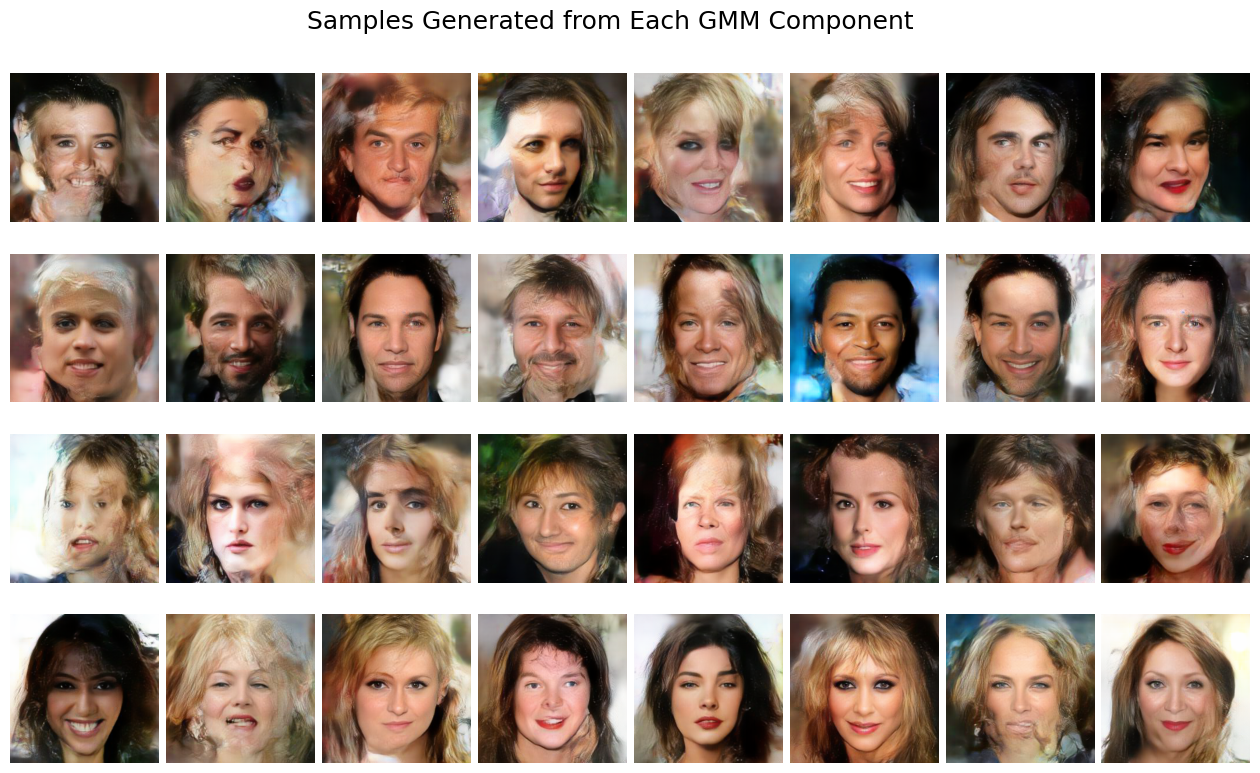

In [3]:
import os
import torch
import torch.nn as nn
import numpy as np
import joblib
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image

# ================================================================
# 1. 기본 설정 및 경로 정의 (사용자 환경에 맞게 확인)
# ================================================================
print("Step 1: 기본 설정 로드")
DEVICE = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

# --- 모델 경로 ---
AE_CHECKPOINT_DIR = '/home/nas/data/YMG/superdeep_ae/checkpoints/'
DECODER_PATH = os.path.join(AE_CHECKPOINT_DIR, 'decoder_superdeep_best.pth')

# --- H-GMM(AIC) 모델 경로 ---
GMM_DIR = '/home/nas/data/YMG/superdeep_ae/hierarchical_gmm_aic_results/'

# ================================================================
# 2. 필요한 클래스 및 함수 정의
# ================================================================
print("Step 2: 모델 클래스 및 함수 정의")
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(nn.Conv2d(in_channels, out_channels, 3, 1, 1), nn.BatchNorm2d(out_channels), nn.SiLU(), nn.Conv2d(out_channels, out_channels, 3, 1, 1), nn.BatchNorm2d(out_channels))
        self.shortcut = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()
        self.silu = nn.SiLU()
    def forward(self, x): return self.silu(self.block(x) + self.shortcut(x))

class DecoderSuperDeep(nn.Module):
    def __init__(self, out_channels=3, base_channels=128, latent_channels=1):
        super().__init__()
        self.decoder = nn.Sequential(nn.Conv2d(latent_channels, base_channels*16, 3, 1, 1), ResBlock(base_channels*16, base_channels*16), nn.Upsample(scale_factor=2, mode='nearest'), nn.Conv2d(base_channels*16, base_channels*8, 3, 1, 1), ResBlock(base_channels*8, base_channels*8), nn.Upsample(scale_factor=2, mode='nearest'), nn.Conv2d(base_channels*8, base_channels*4, 3, 1, 1), ResBlock(base_channels*4, base_channels*4), nn.Upsample(scale_factor=2, mode='nearest'), nn.Conv2d(base_channels*4, base_channels*2, 3, 1, 1), ResBlock(base_channels*2, base_channels*2), nn.Upsample(scale_factor=2, mode='nearest'), nn.Conv2d(base_channels*2, base_channels, 3, 1, 1), ResBlock(base_channels, base_channels), nn.Conv2d(base_channels, out_channels, 3, 1, 1), nn.Tanh())
    def forward(self, z): return self.decoder(z)

def denormalize(tensor):
    return (tensor.clamp(-1, 1) * 0.5) + 0.5

# ================================================================
# 3. 메인 실행 파이프라인
# ================================================================
def main():
    print("\nStep 3.1: 모델 로드")
    decoder = DecoderSuperDeep().to(DEVICE)
    decoder.load_state_dict(torch.load(DECODER_PATH, map_location=DEVICE))
    decoder.eval()
    print("Decoder 모델 로드 완료.")

    # GMM 모델 파일 찾기
    gmm_files = [f for f in os.listdir(GMM_DIR) if f.startswith('hgmm_aic_best_') and f.endswith('.pkl')]
    if not gmm_files:
        print(f"오류: {GMM_DIR}에서 GMM 모델 파일을 찾을 수 없습니다.")
        return
    GMM_PATH = os.path.join(GMM_DIR, sorted(gmm_files)[-1])
    
    gmm_params = joblib.load(GMM_PATH)
    n_components = gmm_params['n_components']
    gmm_means = torch.from_numpy(gmm_params['means']).float().to(DEVICE)
    gmm_covs = torch.from_numpy(gmm_params['covariances']).float().to(DEVICE)
    print(f"GMM 모델 로드 완료: {GMM_PATH} ({n_components}개의 컴포넌트)")

    # --- 샘플링 및 생성 설정 ---
    n_samples_per_component = 8 # 각 컴포넌트에서 생성할 샘플 수

    print(f"\nStep 3.2: 각 컴포넌트에서 {n_samples_per_component}개씩 샘플링 및 이미지 생성")
    
    # 시각화를 위한 subplot 생성
    fig, axes = plt.subplots(n_components, n_samples_per_component, figsize=(n_samples_per_component * 2, n_components * 2.2))
    
    # Figure 전체 제목 설정
    fig.suptitle('Samples Generated from Each GMM Component', fontsize=18)

    with torch.no_grad():
        for i in range(n_components):
            print(f" - Component #{i} 생성 중...")
            
            # i번째 컴포넌트의 평균과 공분산
            mean = gmm_means[i]
            covariance = gmm_covs[i]
            
            # 해당 분포에서 잠재 벡터 샘플링
            dist = torch.distributions.MultivariateNormal(mean, covariance)
            sampled_latents = dist.sample((n_samples_per_component,)) # (n_samples, 256)
            
            # 디코더 입력 형태로 변환: (batch, channels, height, width)
            sampled_latents = sampled_latents.view(n_samples_per_component, 1, 16, 16).to(DEVICE)
            
            # 이미지 생성
            generated_images = decoder(sampled_latents).cpu()
            generated_images = denormalize(generated_images)
            
            # 생성된 이미지 시각화
            # 각 행의 제목 (어떤 컴포넌트인지 표시)
            axes[i, 0].set_ylabel(f'Comp. #{i}\n(Var: {np.diag(covariance.cpu().numpy()).mean():.2f})', rotation=0, size='large', labelpad=40, ha='right', va='center')
            for j in range(n_samples_per_component):
                ax = axes[i, j]
                ax.imshow(generated_images[j].permute(1, 2, 0))
                ax.axis('off')

    plt.subplots_adjust(top=0.92, wspace=0.05, hspace=0.05)
    plt.show()

if __name__ == '__main__':
    main()

Row 0 (Component #0): 평균적인 다양성을 가진 얼굴들이 나타납니다.

Row 1 (Component #1): Component #0과 비슷하게 평균적인 다양성을 보이지만, 다른 종류의 특징을 공유하는 얼굴들이 나타납니다.

Row 2 (Component #2): 가장 다양한 모습의 얼굴들이 나타날 것으로 예상됩니다. 헤어스타일, 표정, 조명 등이 다른 행에 비해 다채로울 것입니다. (평균 분산이 가장 높았음)

Row 3 (Component #3): 가장 비슷비슷한 모습의 얼굴들이 나타날 것입니다. 거의 같은 구도와 표정을 가진 획일적인 이미지가 생성될 확률이 높습니다. (평균 분산이 가장 낮았음)

Step 1: 기본 설정 로드
Step 2: 모델 클래스 정의

Step 3.1: 모델 및 데이터 로드


/tmp/ipykernel_2621594/4072792667.py:66: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  encoder.load_state_dict(torch.load(ENCODER_PATH, map_location=DEVICE))



Step 3.2: 잠재 벡터 추출 및 클러스터 할당


잠재 벡터(mu) 추출 중:   0%|          | 0/79 [00:00<?, ?it/s]

클러스터 할당 중:   0%|          | 0/4 [00:00<?, ?it/s]


Step 3.3: PCA를 이용한 3차원 차원 축소
PCA 설명 분산: [0.11184403 0.04129117 0.03393886]
3개 주성분의 총 설명력: 18.71%

Step 3.4: Matplotlib을 이용한 3D 시각화


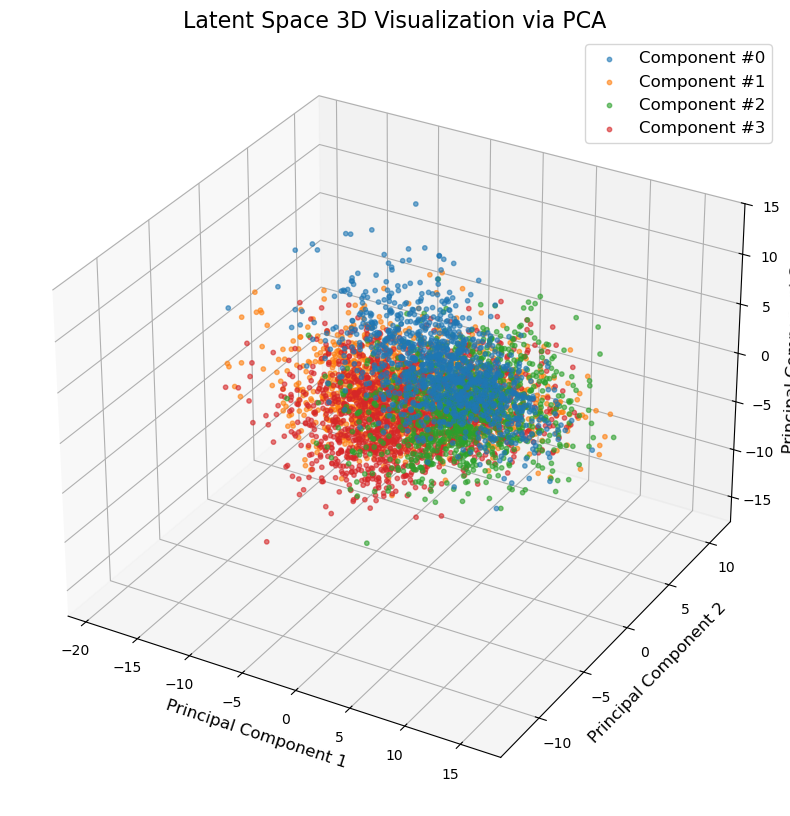

In [5]:
import os
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
from tqdm.auto import tqdm
import joblib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 3D 시각화를 위해 필수
from sklearn.decomposition import PCA   # PCA를 위해 필수

# ================================================================
# 1. 기본 설정 및 경로 정의 (사용자 환경에 맞게 확인)
# ================================================================
print("Step 1: 기본 설정 로드")
DEVICE = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
DATA_DIR = '/home/nas/data/YMG/datas/celeba_hq_256/'

# --- 모델 경로 ---
AE_CHECKPOINT_DIR = '/home/nas/data/YMG/superdeep_ae/checkpoints/'
ENCODER_PATH = os.path.join(AE_CHECKPOINT_DIR, 'encoder_superdeep_best.pth')

# --- H-GMM(AIC) 모델 경로 ---
GMM_DIR = '/home/nas/data/YMG/superdeep_ae/hierarchical_gmm_aic_results/'
OUTPUT_DIR = GMM_DIR

# ================================================================
# 2. 필요한 클래스 및 함수 정의 (Encoder만 필요)
# ================================================================
print("Step 2: 모델 클래스 정의")
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(nn.Conv2d(in_channels, out_channels, 3, 1, 1), nn.BatchNorm2d(out_channels), nn.SiLU(), nn.Conv2d(out_channels, out_channels, 3, 1, 1), nn.BatchNorm2d(out_channels))
        self.shortcut = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()
        self.silu = nn.SiLU()
    def forward(self, x): return self.silu(self.block(x) + self.shortcut(x))

class EncoderSuperDeep(nn.Module):
    def __init__(self, in_channels=3, base_channels=128, latent_channels=1):
        super().__init__()
        self.encoder = nn.Sequential(nn.Conv2d(in_channels, base_channels, 3, 1, 1), ResBlock(base_channels, base_channels), nn.Conv2d(base_channels, base_channels*2, 3, 2, 1), ResBlock(base_channels*2, base_channels*2), nn.Conv2d(base_channels*2, base_channels*4, 3, 2, 1), ResBlock(base_channels*4, base_channels*4), nn.Conv2d(base_channels*4, base_channels*8, 3, 2, 1), ResBlock(base_channels*8, base_channels*8), nn.Conv2d(base_channels*8, base_channels*16, 3, 2, 1), ResBlock(base_channels*16, base_channels*16), nn.Conv2d(base_channels*16, 2 * latent_channels, 3, 1, 1))
    def forward(self, x):
        x = self.encoder(x)
        mu, log_var = torch.chunk(x, 2, dim=1)
        return mu, log_var

class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.paths = sorted([os.path.join(root_dir, f) for f in os.listdir(root_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))])
        self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, idx

# ================================================================
# 3. 메인 실행 파이프라인
# ================================================================
def main():
    print("\nStep 3.1: 모델 및 데이터 로드")
    encoder = EncoderSuperDeep().to(DEVICE)
    encoder.load_state_dict(torch.load(ENCODER_PATH, map_location=DEVICE))
    encoder.eval()

    # GMM 모델 로드
    gmm_files = [f for f in os.listdir(GMM_DIR) if f.startswith('hgmm_aic_best_') and f.endswith('.pkl')]
    if not gmm_files: return
    GMM_PATH = os.path.join(GMM_DIR, sorted(gmm_files)[-1])
    gmm_params = joblib.load(GMM_PATH)
    n_components = gmm_params['n_components']
    gmm_means = torch.from_numpy(gmm_params['means']).float().to(DEVICE)
    gmm_covs = torch.from_numpy(gmm_params['covariances']).float().to(DEVICE)

    # 데이터 로더 설정 (분석할 데이터 수 조절 가능)
    transform = transforms.Compose([transforms.Resize((256, 256)), transforms.ToTensor(), transforms.Normalize(mean=[0.5], std=[0.5])])
    dataset_full = CustomImageDataset(DATA_DIR, transform)
    # 3D 시각화는 너무 많으면 느려지므로 5000개 샘플로 제한
    dataset = Subset(dataset_full, list(range(5000))) 
    loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=4)

    print("\nStep 3.2: 잠재 벡터 추출 및 클러스터 할당")
    all_mu_vectors_flat = []
    with torch.no_grad():
        for imgs, _ in tqdm(loader, desc="잠재 벡터(mu) 추출 중"):
            imgs = imgs.to(DEVICE)
            mu, _ = encoder(imgs)
            all_mu_vectors_flat.append(mu.view(mu.size(0), -1))
    all_mu_vectors_flat = torch.cat(all_mu_vectors_flat, dim=0)
    
    log_probs = []
    for k in tqdm(range(n_components), desc="클러스터 할당 중"):
        dist = torch.distributions.MultivariateNormal(gmm_means[k], gmm_covs[k])
        log_probs.append(dist.log_prob(all_mu_vectors_flat))
    assignments = torch.argmax(torch.stack(log_probs, dim=1), dim=1)

    print("\nStep 3.3: PCA를 이용한 3차원 차원 축소")
    mu_vectors_np = all_mu_vectors_flat.cpu().numpy()
    assignments_np = assignments.cpu().numpy()

    pca = PCA(n_components=3)
    mu_3d = pca.fit_transform(mu_vectors_np)

    # 3개의 주성분이 원본 데이터의 분산을 얼마나 설명하는지 확인
    explained_variance = pca.explained_variance_ratio_
    print(f"PCA 설명 분산: {explained_variance}")
    print(f"3개 주성분의 총 설명력: {sum(explained_variance) * 100:.2f}%")

    print("\nStep 3.4: Matplotlib을 이용한 3D 시각화")
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # 각 컴포넌트(클러스터)별로 다른 색상으로 점 찍기
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Blue, Orange, Green, Red
    for i in range(n_components):
        mask = (assignments_np == i)
        ax.scatter(mu_3d[mask, 0], mu_3d[mask, 1], mu_3d[mask, 2], 
                   c=colors[i], label=f'Component #{i}', alpha=0.6, s=10)

    # 그래프 제목 및 축 레이블 설정
    ax.set_title('Latent Space 3D Visualization via PCA', fontsize=16) # 그래프 제목
    ax.set_xlabel('Principal Component 1', fontsize=12) # x축 이름
    ax.set_ylabel('Principal Component 2', fontsize=12) # y축 이름
    ax.set_zlabel('Principal Component 3', fontsize=12) # z축 이름
    
    ax.legend(fontsize=12)
    plt.show()

if __name__ == '__main__':
    main()

Step 1: 기본 설정 로드
Step 2: 모델 클래스 정의

Step 3.1: 모델 및 데이터 로드


/tmp/ipykernel_2621594/3764863499.py:66: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  encoder.load_state_dict(torch.load(ENCODER_PATH, map_location=DEVICE))



Step 3.2: 잠재 벡터 추출 및 클러스터 할당


잠재 벡터(mu) 추출 중:   0%|          | 0/79 [00:00<?, ?it/s]

클러스터 할당 중:   0%|          | 0/4 [00:00<?, ?it/s]


Step 3.3: PCA를 이용한 3차원 차원 축소

Step 3.4: Matplotlib을 이용한 2D 투영 시각화


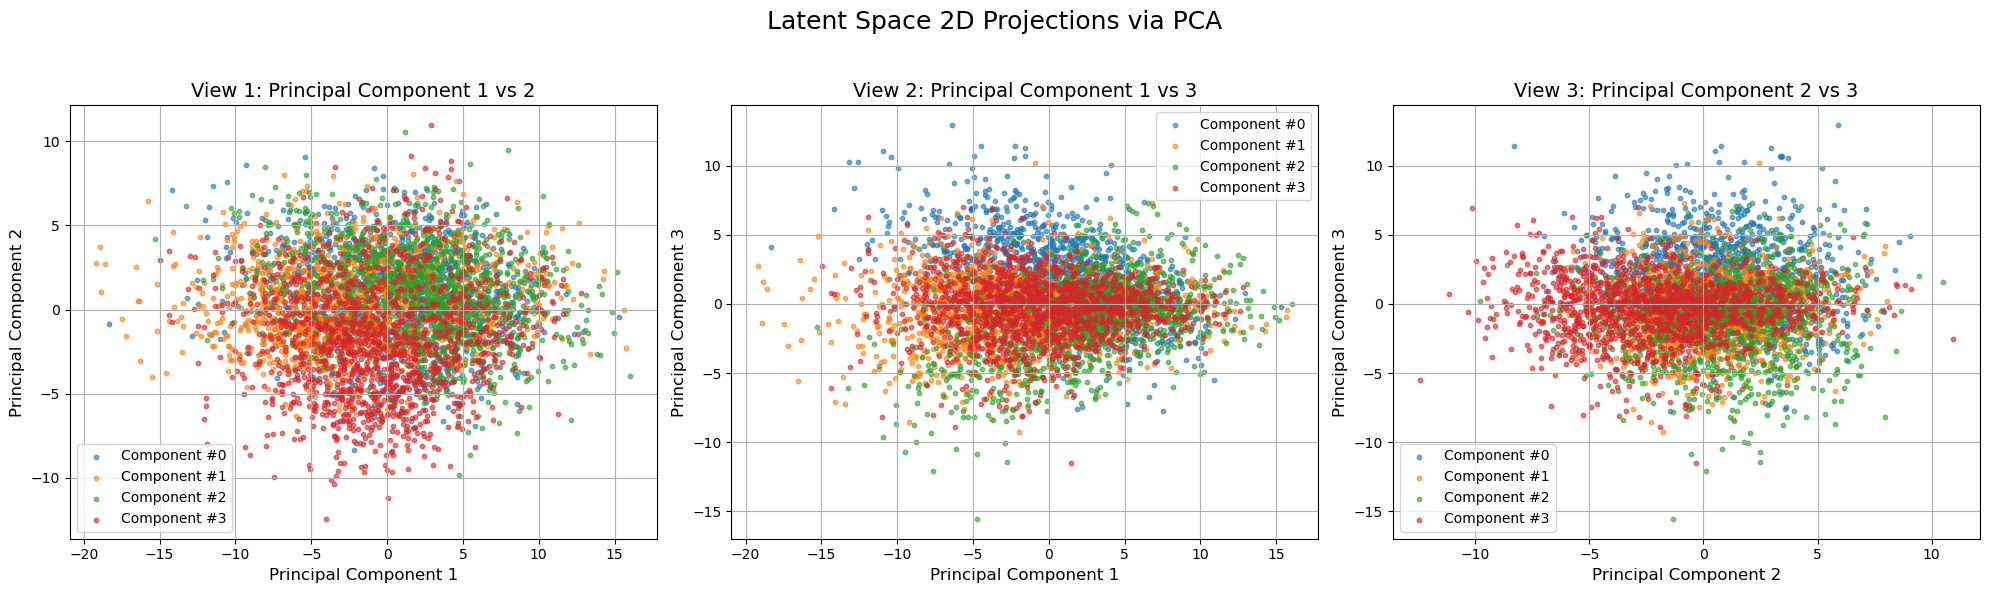

In [7]:
import os
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
from tqdm.auto import tqdm
import joblib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 3D 시각화를 위해 필수
from sklearn.decomposition import PCA   # PCA를 위해 필수

# ================================================================
# 1. 기본 설정 및 경로 정의 (사용자 환경에 맞게 확인)
# ================================================================
print("Step 1: 기본 설정 로드")
DEVICE = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
DATA_DIR = '/home/nas/data/YMG/datas/celeba_hq_256/'

# --- 모델 경로 ---
AE_CHECKPOINT_DIR = '/home/nas/data/YMG/superdeep_ae/checkpoints/'
ENCODER_PATH = os.path.join(AE_CHECKPOINT_DIR, 'encoder_superdeep_best.pth')

# --- H-GMM(AIC) 모델 경로 ---
GMM_DIR = '/home/nas/data/YMG/superdeep_ae/hierarchical_gmm_aic_results/'
OUTPUT_DIR = GMM_DIR

# ================================================================
# 2. 필요한 클래스 및 함수 정의 (Encoder만 필요)
# ================================================================
print("Step 2: 모델 클래스 정의")
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(nn.Conv2d(in_channels, out_channels, 3, 1, 1), nn.BatchNorm2d(out_channels), nn.SiLU(), nn.Conv2d(out_channels, out_channels, 3, 1, 1), nn.BatchNorm2d(out_channels))
        self.shortcut = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()
        self.silu = nn.SiLU()
    def forward(self, x): return self.silu(self.block(x) + self.shortcut(x))

class EncoderSuperDeep(nn.Module):
    def __init__(self, in_channels=3, base_channels=128, latent_channels=1):
        super().__init__()
        self.encoder = nn.Sequential(nn.Conv2d(in_channels, base_channels, 3, 1, 1), ResBlock(base_channels, base_channels), nn.Conv2d(base_channels, base_channels*2, 3, 2, 1), ResBlock(base_channels*2, base_channels*2), nn.Conv2d(base_channels*2, base_channels*4, 3, 2, 1), ResBlock(base_channels*4, base_channels*4), nn.Conv2d(base_channels*4, base_channels*8, 3, 2, 1), ResBlock(base_channels*8, base_channels*8), nn.Conv2d(base_channels*8, base_channels*16, 3, 2, 1), ResBlock(base_channels*16, base_channels*16), nn.Conv2d(base_channels*16, 2 * latent_channels, 3, 1, 1))
    def forward(self, x):
        x = self.encoder(x)
        mu, log_var = torch.chunk(x, 2, dim=1)
        return mu, log_var

class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.paths = sorted([os.path.join(root_dir, f) for f in os.listdir(root_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))])
        self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, idx

# ================================================================
# 3. 메인 실행 파이프라인
# ================================================================
def main():
    print("\nStep 3.1: 모델 및 데이터 로드")
    encoder = EncoderSuperDeep().to(DEVICE)
    encoder.load_state_dict(torch.load(ENCODER_PATH, map_location=DEVICE))
    encoder.eval()

    # GMM 모델 로드
    gmm_files = [f for f in os.listdir(GMM_DIR) if f.startswith('hgmm_aic_best_') and f.endswith('.pkl')]
    if not gmm_files: return
    GMM_PATH = os.path.join(GMM_DIR, sorted(gmm_files)[-1])
    gmm_params = joblib.load(GMM_PATH)
    n_components = gmm_params['n_components']
    gmm_means = torch.from_numpy(gmm_params['means']).float().to(DEVICE)
    gmm_covs = torch.from_numpy(gmm_params['covariances']).float().to(DEVICE)

    # 데이터 로더 설정 (분석할 데이터 수 조절 가능)
    transform = transforms.Compose([transforms.Resize((256, 256)), transforms.ToTensor(), transforms.Normalize(mean=[0.5], std=[0.5])])
    dataset_full = CustomImageDataset(DATA_DIR, transform)
    # 3D 시각화는 너무 많으면 느려지므로 5000개 샘플로 제한
    dataset = Subset(dataset_full, list(range(5000))) 
    loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=4)

    print("\nStep 3.2: 잠재 벡터 추출 및 클러스터 할당")
    all_mu_vectors_flat = []
    with torch.no_grad():
        for imgs, _ in tqdm(loader, desc="잠재 벡터(mu) 추출 중"):
            imgs = imgs.to(DEVICE)
            mu, _ = encoder(imgs)
            all_mu_vectors_flat.append(mu.view(mu.size(0), -1))
    all_mu_vectors_flat = torch.cat(all_mu_vectors_flat, dim=0)
    
    log_probs = []
    for k in tqdm(range(n_components), desc="클러스터 할당 중"):
        dist = torch.distributions.MultivariateNormal(gmm_means[k], gmm_covs[k])
        log_probs.append(dist.log_prob(all_mu_vectors_flat))
    assignments = torch.argmax(torch.stack(log_probs, dim=1), dim=1)

    print("\nStep 3.3: PCA를 이용한 3차원 차원 축소")
    mu_vectors_np = all_mu_vectors_flat.cpu().numpy()
    assignments_np = assignments.cpu().numpy()

    pca = PCA(n_components=3)
    mu_3d = pca.fit_transform(mu_vectors_np)


    # ... (이전 단계의 코드: Step 1 ~ Step 3.3 까지는 모두 동일) ...
    # ... (PCA를 통해 mu_3d를 계산한 직후) ...

    print("\nStep 3.4: Matplotlib을 이용한 2D 투영 시각화")
    # 1x3 형태의 서브플롯을 생성
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # 각 컴포넌트(클러스터)별로 다른 색상으로 점 찍기
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Blue, Orange, Green, Red
    component_labels = [f'Component #{i}' for i in range(n_components)]

    # --- 첫 번째 그래프: PC1 vs PC2 ---
    ax1 = axes[0]
    for i in range(n_components):
        mask = (assignments_np == i)
        ax1.scatter(mu_3d[mask, 0], mu_3d[mask, 1], 
                    c=colors[i], label=component_labels[i], alpha=0.6, s=10)
    # 첫 번째 그래프 제목 및 축 이름
    ax1.set_title('View 1: Principal Component 1 vs 2', fontsize=14) 
    ax1.set_xlabel('Principal Component 1', fontsize=12)
    ax1.set_ylabel('Principal Component 2', fontsize=12)
    ax1.grid(True)
    ax1.legend()


    # --- 두 번째 그래프: PC1 vs PC3 ---
    ax2 = axes[1]
    for i in range(n_components):
        mask = (assignments_np == i)
        ax2.scatter(mu_3d[mask, 0], mu_3d[mask, 2], 
                    c=colors[i], label=component_labels[i], alpha=0.6, s=10)
    # 두 번째 그래프 제목 및 축 이름
    ax2.set_title('View 2: Principal Component 1 vs 3', fontsize=14) 
    ax2.set_xlabel('Principal Component 1', fontsize=12)
    ax2.set_ylabel('Principal Component 3', fontsize=12)
    ax2.grid(True)
    ax2.legend()


    # --- 세 번째 그래프: PC2 vs PC3 ---
    ax3 = axes[2]
    for i in range(n_components):
        mask = (assignments_np == i)
        ax3.scatter(mu_3d[mask, 1], mu_3d[mask, 2], 
                    c=colors[i], label=component_labels[i], alpha=0.6, s=10)
    # 세 번째 그래프 제목 및 축 이름
    ax3.set_title('View 3: Principal Component 2 vs 3', fontsize=14) 
    ax3.set_xlabel('Principal Component 2', fontsize=12)
    ax3.set_ylabel('Principal Component 3', fontsize=12)
    ax3.grid(True)
    ax3.legend()

    # 전체 제목
    fig.suptitle('Latent Space 2D Projections via PCA', fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

if __name__ == '__main__':
    main()

Step 1: 기본 설정 로드
Step 2: 모델 클래스 정의

Step 3.1: 모델 및 데이터 로드


/tmp/ipykernel_2621594/2953243782.py:66: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  encoder.load_state_dict(torch.load(ENCODER_PATH, map_location=DEVICE))



Step 3.2: 잠재 벡터 추출 및 클러스터 할당


잠재 벡터(mu) 추출 중:   0%|          | 0/79 [00:00<?, ?it/s]

클러스터 할당 중:   0%|          | 0/4 [00:00<?, ?it/s]


Step 3.3: PCA를 이용한 3차원 차원 축소

Step 3.4: Seaborn을 이용한 KDE 분포 시각화


/tmp/ipykernel_2621594/2953243782.py:128: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
/tmp/ipykernel_2621594/2953243782.py:142: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()
/tmp/ipykernel_2621594/2953243782.py:156: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend()


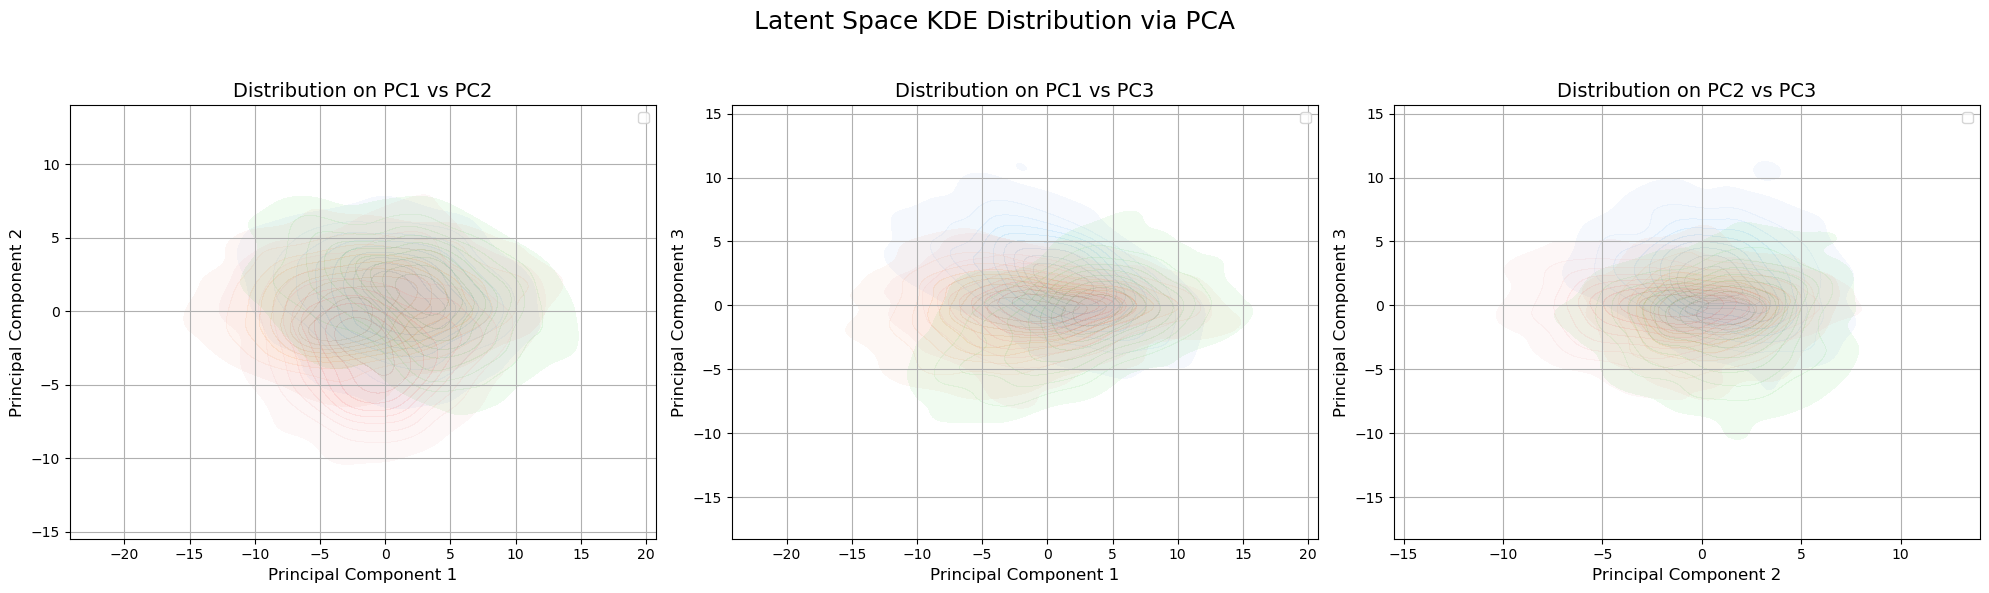

In [9]:
import os
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
from tqdm.auto import tqdm
import joblib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 3D 시각화를 위해 필수
from sklearn.decomposition import PCA   # PCA를 위해 필수

# ================================================================
# 1. 기본 설정 및 경로 정의 (사용자 환경에 맞게 확인)
# ================================================================
print("Step 1: 기본 설정 로드")
DEVICE = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
DATA_DIR = '/home/nas/data/YMG/datas/celeba_hq_256/'

# --- 모델 경로 ---
AE_CHECKPOINT_DIR = '/home/nas/data/YMG/superdeep_ae/checkpoints/'
ENCODER_PATH = os.path.join(AE_CHECKPOINT_DIR, 'encoder_superdeep_best.pth')

# --- H-GMM(AIC) 모델 경로 ---
GMM_DIR = '/home/nas/data/YMG/superdeep_ae/hierarchical_gmm_aic_results/'
OUTPUT_DIR = GMM_DIR

# ================================================================
# 2. 필요한 클래스 및 함수 정의 (Encoder만 필요)
# ================================================================
print("Step 2: 모델 클래스 정의")
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(nn.Conv2d(in_channels, out_channels, 3, 1, 1), nn.BatchNorm2d(out_channels), nn.SiLU(), nn.Conv2d(out_channels, out_channels, 3, 1, 1), nn.BatchNorm2d(out_channels))
        self.shortcut = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()
        self.silu = nn.SiLU()
    def forward(self, x): return self.silu(self.block(x) + self.shortcut(x))

class EncoderSuperDeep(nn.Module):
    def __init__(self, in_channels=3, base_channels=128, latent_channels=1):
        super().__init__()
        self.encoder = nn.Sequential(nn.Conv2d(in_channels, base_channels, 3, 1, 1), ResBlock(base_channels, base_channels), nn.Conv2d(base_channels, base_channels*2, 3, 2, 1), ResBlock(base_channels*2, base_channels*2), nn.Conv2d(base_channels*2, base_channels*4, 3, 2, 1), ResBlock(base_channels*4, base_channels*4), nn.Conv2d(base_channels*4, base_channels*8, 3, 2, 1), ResBlock(base_channels*8, base_channels*8), nn.Conv2d(base_channels*8, base_channels*16, 3, 2, 1), ResBlock(base_channels*16, base_channels*16), nn.Conv2d(base_channels*16, 2 * latent_channels, 3, 1, 1))
    def forward(self, x):
        x = self.encoder(x)
        mu, log_var = torch.chunk(x, 2, dim=1)
        return mu, log_var

class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.paths = sorted([os.path.join(root_dir, f) for f in os.listdir(root_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))])
        self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, idx

# ================================================================
# 3. 메인 실행 파이프라인
# ================================================================
def main():
    print("\nStep 3.1: 모델 및 데이터 로드")
    encoder = EncoderSuperDeep().to(DEVICE)
    encoder.load_state_dict(torch.load(ENCODER_PATH, map_location=DEVICE))
    encoder.eval()

    # GMM 모델 로드
    gmm_files = [f for f in os.listdir(GMM_DIR) if f.startswith('hgmm_aic_best_') and f.endswith('.pkl')]
    if not gmm_files: return
    GMM_PATH = os.path.join(GMM_DIR, sorted(gmm_files)[-1])
    gmm_params = joblib.load(GMM_PATH)
    n_components = gmm_params['n_components']
    gmm_means = torch.from_numpy(gmm_params['means']).float().to(DEVICE)
    gmm_covs = torch.from_numpy(gmm_params['covariances']).float().to(DEVICE)

    # 데이터 로더 설정 (분석할 데이터 수 조절 가능)
    transform = transforms.Compose([transforms.Resize((256, 256)), transforms.ToTensor(), transforms.Normalize(mean=[0.5], std=[0.5])])
    dataset_full = CustomImageDataset(DATA_DIR, transform)
    # 3D 시각화는 너무 많으면 느려지므로 5000개 샘플로 제한
    dataset = Subset(dataset_full, list(range(5000))) 
    loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=4)

    print("\nStep 3.2: 잠재 벡터 추출 및 클러스터 할당")
    all_mu_vectors_flat = []
    with torch.no_grad():
        for imgs, _ in tqdm(loader, desc="잠재 벡터(mu) 추출 중"):
            imgs = imgs.to(DEVICE)
            mu, _ = encoder(imgs)
            all_mu_vectors_flat.append(mu.view(mu.size(0), -1))
    all_mu_vectors_flat = torch.cat(all_mu_vectors_flat, dim=0)
    
    log_probs = []
    for k in tqdm(range(n_components), desc="클러스터 할당 중"):
        dist = torch.distributions.MultivariateNormal(gmm_means[k], gmm_covs[k])
        log_probs.append(dist.log_prob(all_mu_vectors_flat))
    assignments = torch.argmax(torch.stack(log_probs, dim=1), dim=1)

    print("\nStep 3.3: PCA를 이용한 3차원 차원 축소")
    mu_vectors_np = all_mu_vectors_flat.cpu().numpy()
    assignments_np = assignments.cpu().numpy()

    pca = PCA(n_components=3)
    mu_3d = pca.fit_transform(mu_vectors_np)

    # ... (이전 단계의 코드: Step 1 ~ Step 3.3 까지는 모두 동일) ...
    # ... (PCA를 통해 mu_3d를 계산한 직후) ...
    import seaborn as sns # seaborn 라이브러리 임포트

    print("\nStep 3.4: Seaborn을 이용한 KDE 분포 시각화")
    # 1x3 형태의 서브플롯을 생성
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    # --- 첫 번째 그래프: PC1 vs PC2 분포 ---
    ax1 = axes[0]
    for i in range(n_components):
        mask = (assignments_np == i)
        sns.kdeplot(x=mu_3d[mask, 0], y=mu_3d[mask, 1], 
                    ax=ax1, color=colors[i], label=f'Component #{i}', fill=True, alpha=0.1)
    # 첫 번째 그래프 제목 및 축 이름
    ax1.set_title('Distribution on PC1 vs PC2', fontsize=14)
    ax1.set_xlabel('Principal Component 1', fontsize=12)
    ax1.set_ylabel('Principal Component 2', fontsize=12)
    ax1.grid(True)
    ax1.legend()


    # --- 두 번째 그래프: PC1 vs PC3 분포 ---
    ax2 = axes[1]
    for i in range(n_components):
        mask = (assignments_np == i)
        sns.kdeplot(x=mu_3d[mask, 0], y=mu_3d[mask, 2], 
                    ax=ax2, color=colors[i], label=f'Component #{i}', fill=True, alpha=0.1)
    # 두 번째 그래프 제목 및 축 이름
    ax2.set_title('Distribution on PC1 vs PC3', fontsize=14)
    ax2.set_xlabel('Principal Component 1', fontsize=12)
    ax2.set_ylabel('Principal Component 3', fontsize=12)
    ax2.grid(True)
    ax2.legend()


    # --- 세 번째 그래프: PC2 vs PC3 분포 ---
    ax3 = axes[2]
    for i in range(n_components):
        mask = (assignments_np == i)
        sns.kdeplot(x=mu_3d[mask, 1], y=mu_3d[mask, 2], 
                    ax=ax3, color=colors[i], label=f'Component #{i}', fill=True, alpha=0.1)
    # 세 번째 그래프 제목 및 축 이름
    ax3.set_title('Distribution on PC2 vs PC3', fontsize=14)
    ax3.set_xlabel('Principal Component 2', fontsize=12)
    ax3.set_ylabel('Principal Component 3', fontsize=12)
    ax3.grid(True)
    ax3.legend()

    # 전체 제목
    fig.suptitle('Latent Space KDE Distribution via PCA', fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

if __name__ == '__main__':
    main()